# Gaming vs Academic Performance — EDA

Dataset: [aiexplorer77/gaming-vs-academic-performance](https://www.kaggle.com/datasets/aiexplorer77/gaming-vs-academic-performance) (`Gaming_Academic_Performance.csv`).

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display

def _format_linear_eq(m: float, b: float) -> str:
    sign = "+" if b >= 0 else "−"
    return f"y = {m:.5g}x {sign} {abs(b):.5g}"


def _linear_trend_label(data: pd.DataFrame, xcol: str, ycol: str) -> str:
    sub = data[[xcol, ycol]].dropna()
    if len(sub) < 2:
        return ""
    m, b = np.polyfit(sub[xcol].to_numpy(dtype=float), sub[ycol].to_numpy(dtype=float), 1)
    return _format_linear_eq(float(m), float(b))


sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#cfd4da",
        "axes.labelcolor": "#24292f",
        "axes.titlecolor": "#24292f",
        "text.color": "#24292f",
        "xtick.color": "#57606a",
        "ytick.color": "#57606a",
        "grid.color": "#e9ecef",
        "figure.figsize": (11, 5),
    }
)

CSV_BASENAME = "Gaming_Academic_Performance.csv"
KAGGLE_SLUG = "aiexplorer77/gaming-vs-academic-performance"


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "gaming" in p.name.lower() and "academic" in p.name.lower():
                return p
    local = Path("data") / CSV_BASENAME
    if local.exists():
        return local
    path = kagglehub.dataset_download(KAGGLE_SLUG)
    root = Path(path)
    p = root / CSV_BASENAME
    assert p.is_file(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.head())

CSV: /kaggle/input/datasets/aiexplorer77/gaming-vs-academic-performance/Gaming_Academic_Performance.csv
8000 rows × 14 cols


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [2]:
display(df.info())
display(df.describe().T)
missing = df.isna().sum()
print("Missing per column:")
display(missing[missing > 0].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


None

,count,mean,std,min,25%,50%,75%,max
student_id,8000.0,4000.500000,2309.545410,1.00,2000.750000,4000.500,6000.250000,8000.000000
age,8000.0,19.983625,2.587072,16.00,18.000000,20.000,22.000000,24.000000
gaming_hours,8000.0,4.085773,2.308801,0.00,2.130000,4.130,6.060000,8.000000
study_hours,8000.0,5.460581,2.575787,1.00,3.240000,5.460,7.660000,10.000000
sleep_hours,8000.0,6.493453,1.442656,4.00,5.240000,6.505,7.730000,9.000000
attendance,8000.0,79.886525,11.580419,60.00,69.780000,79.695,90.100000,100.000000
social_activity,8000.0,2.507790,1.441128,0.00,1.287500,2.500,3.760000,5.000000
device_usage,8000.0,7.586315,2.710035,1.10,5.560000,7.610,9.600000,13.950000
reaction_time_ms,8000.0,271.105839,29.440675,183.26,247.160000,270.475,294.690000,347.870000
addiction_score,8000.0,9.908492,5.035837,-4.51,5.920000,10.005,13.860000,23.160000


Missing per column:


Series([], dtype: int64)


gender:


gender
Male      3904
Female    3803
Other      293
Name: count, dtype: int64


gaming_genre:


gaming_genre
FPS       3187
RPG       2408
Casual    2405
Name: count, dtype: int64


stress_level:


stress_level
Medium    4247
Low       2743
High      1010
Name: count, dtype: int64

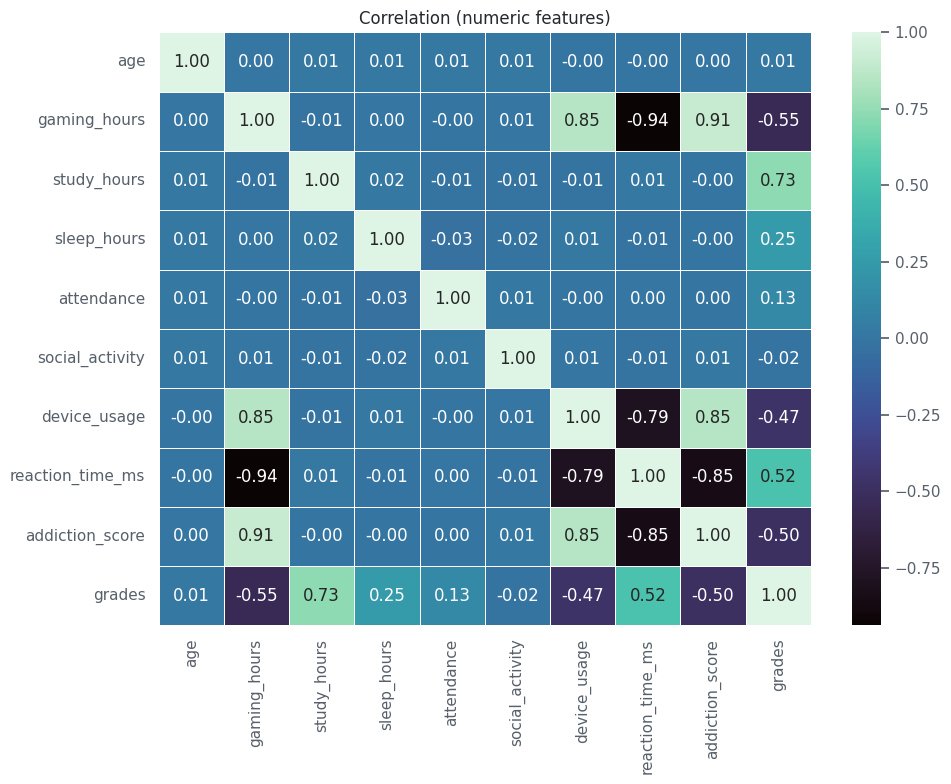

In [3]:
for col in ["gender", "gaming_genre", "stress_level"]:
    print(f"\n{col}:")
    display(df[col].value_counts())

numeric = df.select_dtypes(include=[np.number]).columns.drop("student_id", errors="ignore")
corr = df[numeric].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako", ax=ax, linewidths=0.5)
ax.set_title("Correlation (numeric features)")
plt.tight_layout()
plt.show()

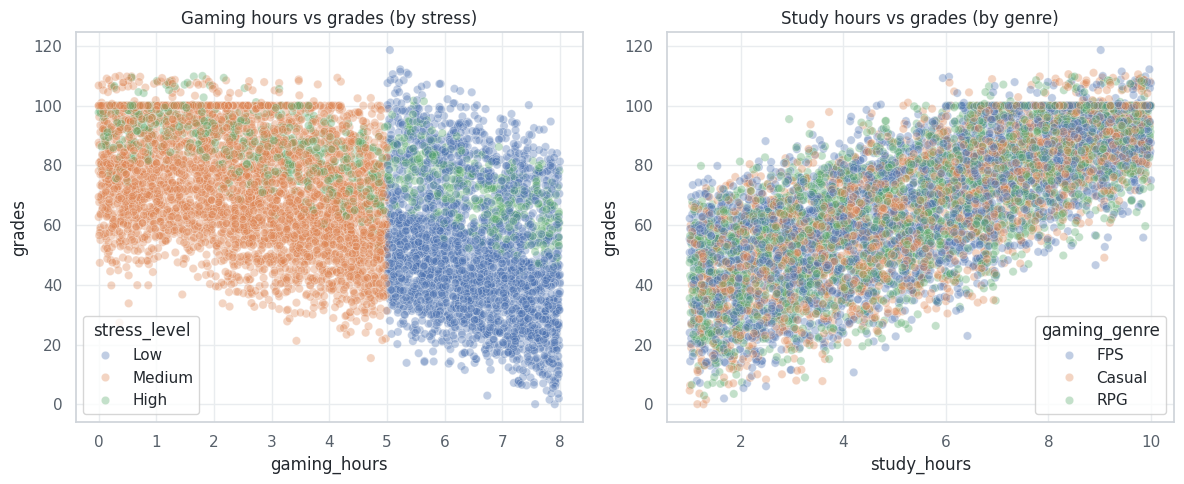

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(
    data=df,
    x="gaming_hours",
    y="grades",
    hue="stress_level",
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Gaming hours vs grades (by stress)")

sns.scatterplot(
    data=df,
    x="study_hours",
    y="grades",
    hue="gaming_genre",
    alpha=0.35,
    ax=axes[1],
)
axes[1].set_title("Study hours vs grades (by genre)")
plt.tight_layout()
plt.show()

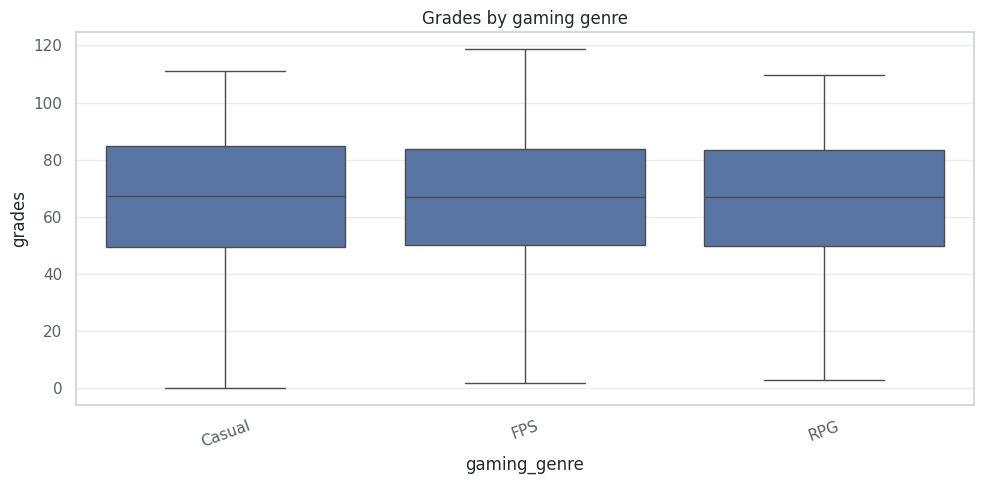

Grades by stress_level:


,count,mean,std,median
stress_level,,,,
Low,2743,50.573928,22.008797,47.36
Medium,4247,72.731780,18.414162,72.08
High,1010,81.019857,13.384594,82.05


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(df["gaming_genre"].unique())
sns.boxplot(data=df, x="gaming_genre", y="grades", order=order, ax=ax)
ax.tick_params(axis="x", rotation=20)
ax.set_title("Grades by gaming genre")
plt.tight_layout()
plt.show()

summary = (
    df.groupby("stress_level", observed=True)["grades"]
    .agg(["count", "mean", "std", "median"])
    .sort_values("mean")
)
print("Grades by stress_level:")
display(summary)

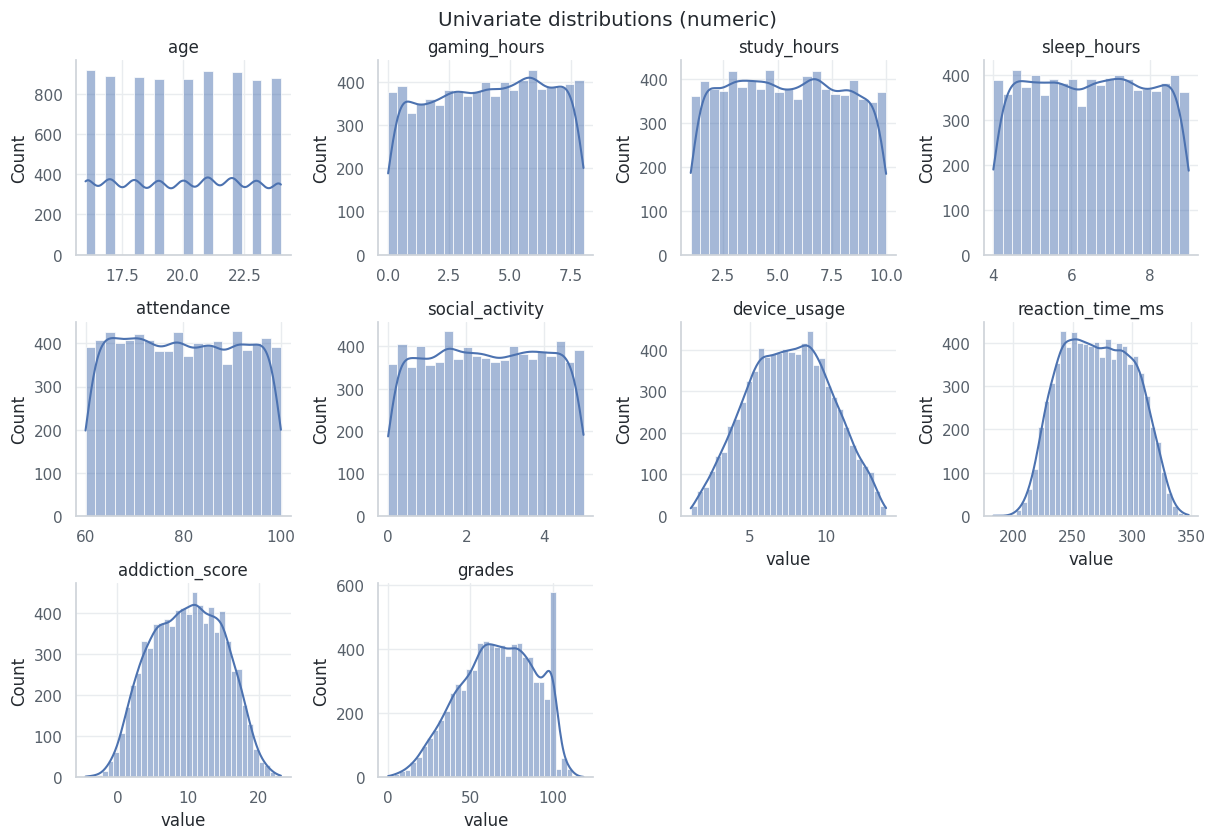

In [6]:
num_cols = (
    df.select_dtypes(include=[np.number])
    .columns.drop("student_id", errors="ignore")
    .tolist()
)
melted_num = df[num_cols].melt(var_name="variable", value_name="value")

uni_num = sns.FacetGrid(
    melted_num,
    col="variable",
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=2.85,
    aspect=1.08,
)
uni_num.map_dataframe(
    sns.histplot,
    x="value",
    kde=True,
    edgecolor="white",
    linewidth=0.5,
)
uni_num.set_titles("{col_name}")
uni_num.figure.subplots_adjust(top=0.92)
uni_num.figure.suptitle("Univariate distributions (numeric)")
plt.show()


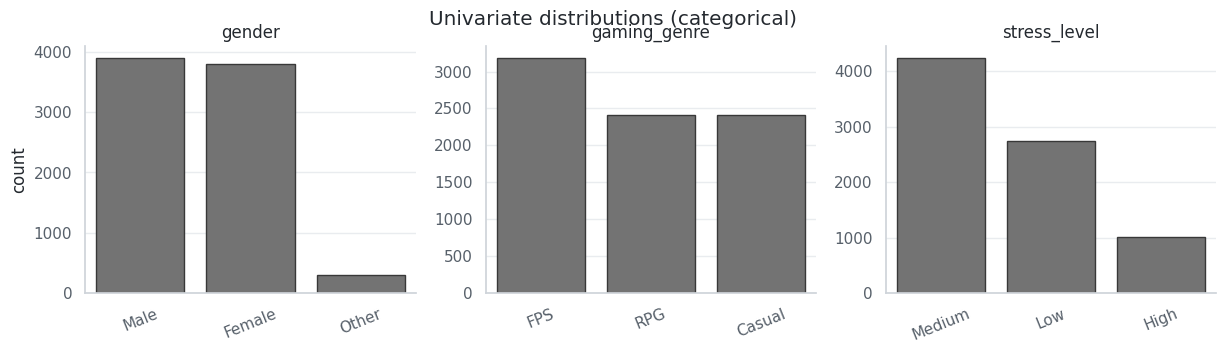

In [7]:
cat_cols = ["gender", "gaming_genre", "stress_level"]
counts_parts = []
for c in cat_cols:
    vc = (
        df[c]
        .astype(str)
        .value_counts()
        .rename_axis("category")
        .reset_index(name="count")
    )
    vc.insert(0, "variable", c)
    counts_parts.append(vc)
cat_long = pd.concat(counts_parts, ignore_index=True)

uni_cat = sns.FacetGrid(
    cat_long,
    col="variable",
    sharex=False,
    sharey=False,
    col_wrap=3,
    height=3.6,
    aspect=1.15,
)
uni_cat.map_dataframe(
    sns.barplot,
    x="category",
    y="count",
    color=".45",
    edgecolor=".22",
)

for ax in uni_cat.axes.flat:
    ax.tick_params(axis="x", rotation=22)
uni_cat.set_xlabels("")
uni_cat.set_titles("{col_name}")
uni_cat.figure.subplots_adjust(top=0.88)
uni_cat.figure.suptitle("Univariate distributions (categorical)")
plt.show()


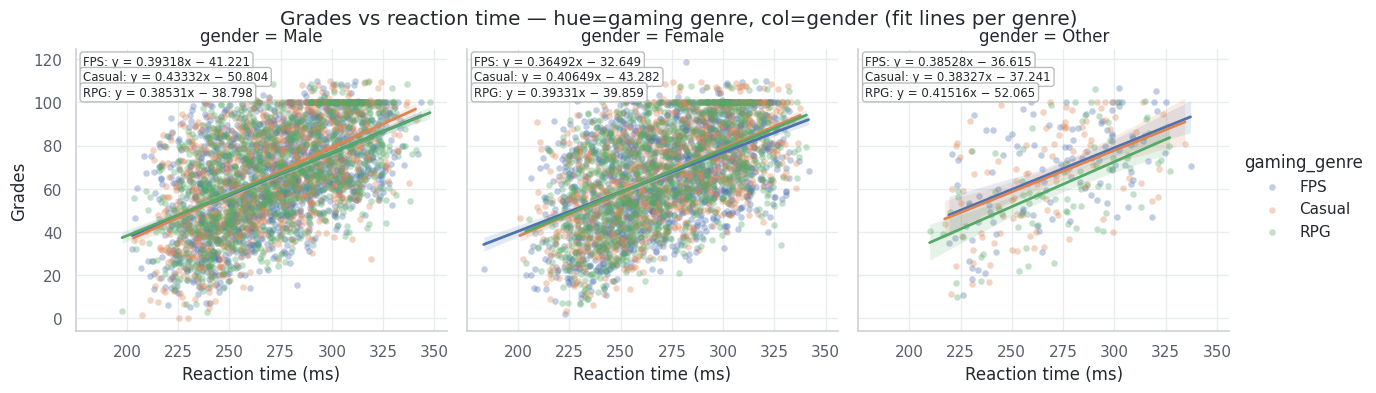

In [8]:
g = sns.lmplot(
    data=df,
    x="reaction_time_ms",
    y="grades",
    hue="gaming_genre",
    col="gender",
    height=4,
    aspect=1.05,
    scatter_kws={"alpha": 0.35, "s": 22, "linewidths": 0},
    line_kws={"linewidth": 2},
)
g.set_axis_labels("Reaction time (ms)", "Grades")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Grades vs reaction time — hue=gaming genre, col=gender (fit lines per genre)")

for ax, col_val in zip(g.axes.flat, g.col_names):
    for j, hue_val in enumerate(g.hue_names):
        part = df[(df["gender"] == col_val) & (df["gaming_genre"] == hue_val)]
        eq = _linear_trend_label(part, "reaction_time_ms", "grades")
        if not eq:
            continue
        ax.text(
            0.02,
            0.98 - 0.055 * j,
            f"{hue_val}: {eq}",
            transform=ax.transAxes,
            fontsize=8.5,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.88),
        )
plt.show()


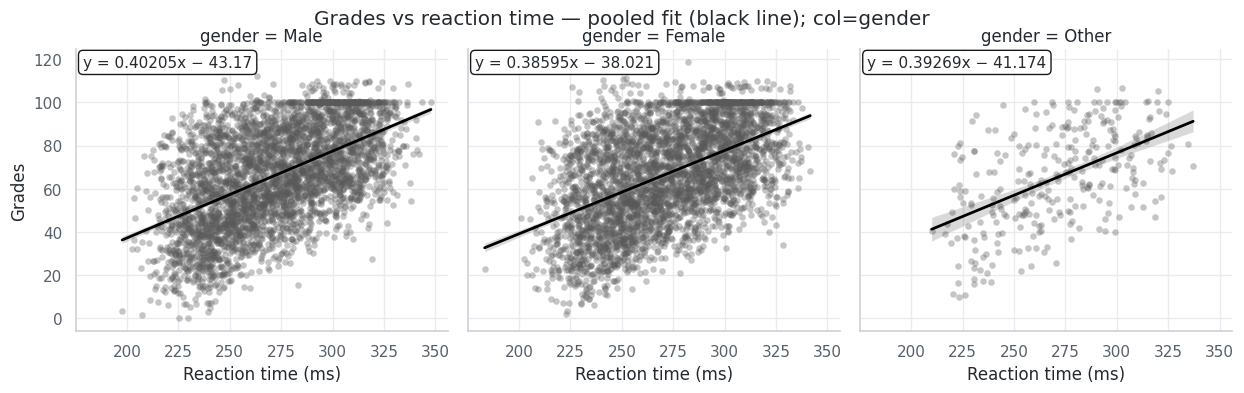

In [9]:
g = sns.lmplot(
    data=df,
    x="reaction_time_ms",
    y="grades",
    col="gender",
    height=4,
    aspect=1.05,
    scatter_kws={"alpha": 0.35, "s": 22, "linewidths": 0, "color": ".35"},
    line_kws={"color": "black", "linewidth": 2},
)
g.set_axis_labels("Reaction time (ms)", "Grades")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Grades vs reaction time — pooled fit (black line); col=gender")

for ax, col_val in zip(g.axes.flat, g.col_names):
    part = df[df["gender"] == col_val]
    eq = _linear_trend_label(part, "reaction_time_ms", "grades")
    if eq:
        ax.text(
            0.02,
            0.98,
            eq,
            transform=ax.transAxes,
            fontsize=11,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.9),
        )
plt.show()
